# Tarea 0 --- IELE756
**Team members**: [Martín Crisóstomo] , [Borja landerretche]
**Region**: [ Your assigned region]
**Date**: [15/03/2026]

Estimado profesor, no logramos identificar con que region debiamos trabajar como grupo por lo cual decidimos realizar nuestra entrega en torno a la region de Tarapaca (1)

In [ ]:
import pandas as pd
print("Hello, IELE756!")
print(f"pandas version: {pd.__version__}")

Hello, IELE756!
pandas version: 2.2.2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
persona = pd.read_parquet("/content/drive/MyDrive/Prep datos/personas_censo2024.parquet",
columns=["region", "comuna", "sexo", "edad",
"p27_nacionalidad", "p27_nacionalidad_rec",
"escolaridad", "sit_fuerza_trabajo"],
)

In [ ]:
persona.shape


(18480432, 8)

In [ ]:
persona.dtypes


,0
region,int32
comuna,int32
sexo,int32
edad,int32
p27_nacionalidad,int32
p27_nacionalidad_rec,int32
escolaridad,int32
sit_fuerza_trabajo,float64


#1.2 inspección

podemos ver que la tabla extraida con los datos del censo cuenta con 18.480.432 filas de entradas y 8 columnas.
La mayoría de los datos corresponden a tipos numericos, siendo 7 de las columnas numeros enteros y una siendo decimal.


In [ ]:
persona.head(10)


,region,comuna,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,sit_fuerza_trabajo
0,5,5802,2,80,1,1,17,3.0
1,5,5802,1,52,1,1,14,1.0
2,5,5802,2,45,1,1,12,1.0
3,5,5802,2,8,1,1,2,NaN
4,4,4303,1,69,1,1,12,3.0
5,4,4303,2,65,1,1,12,3.0
6,4,4303,1,58,1,1,15,1.0
7,11,11202,2,-66,-66,1,8,1.0
8,11,11202,1,-66,-66,1,5,1.0
9,11,11202,1,-66,-66,1,3,NaN


In [ ]:
persona.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18480432 entries, 0 to 18480431
Data columns (total 8 columns):
 #   Column                Dtype  
---  ------                -----  
 0   region                int32  
 1   comuna                int32  
 2   sexo                  int32  
 3   edad                  int32  
 4   p27_nacionalidad      int32  
 5   p27_nacionalidad_rec  int32  
 6   escolaridad           int32  
 7   sit_fuerza_trabajo    float64
dtypes: float64(1), int32(7)
memory usage: 634.5 MB


1.3 Filtrado por region


Esto reduce el dataset nacional (~19 millones de registros) a solo
las personas que viven en nuestra región.

In [ ]:
# region es numérico en el Censo
tarapaca = persona[persona["region"] == 1]
print(f"Tarapacá: {len(tarapaca):,} personas")

Tarapacá: 369,806 personas


1.4 Nacionalidad

Para explorar la composición de nacionalidad en nuestra región,
calculamos la distribución de la variable p27_nacionalidad_rec
usando .value_counts().

Esta variable corresponde a una versión recodificada de la
nacionalidad que distingue entre chilenos y extranjeros.

Luego calculamos el porcentaje de residentes nacidos en el
extranjero utilizando la versión normalizada de value_counts().

In [ ]:
import numpy as np
# Códigos: 1=Chileno, 2=Chileno+otra, 3=Extranjero, -99=NR
print(tarapaca["p27_nacionalidad"].value_counts())

# Variable recodificada (más conveniente)
print(tarapaca["p27_nacionalidad_rec"].value_counts())

# Reemplazar -99 por NaN
tarapaca["p27_nacionalidad_rec"] = tarapaca["p27_nacionalidad_rec"].replace(-99, np.nan)

# Calcular porcentajes ignorando NaN
foreign_percentages = tarapaca["p27_nacionalidad_rec"].value_counts(normalize=True)

print(f"% extranjeros: {foreign_percentages.get(2,0):.1%}")


p27_nacionalidad
 1     276259
 3      79476
 2       6149
-66      4983
-99      2939
Name: count, dtype: int64
p27_nacionalidad_rec
1.0    286268
2.0     80574
Name: count, dtype: int64
% extranjeros: 22.0%


/tmp/ipykernel_217/2580543912.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tarapaca["p27_nacionalidad_rec"] = tarapaca["p27_nacionalidad_rec"].replace(-99, np.nan)


El porcentaje de extranjeros residentes en la region de tarapaca es de un 22% de los encuestados

PARTE 2. ENO

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

2.1 Carga de datos

In [ ]:
eno = pd.read_csv(
    "/content/drive/MyDrive/Prep datos/20241218_base_eno_final.csv",
    sep=";", encoding="utf-8-sig"
)

print(f"Total: {len(eno):,}")
print(eno.columns.tolist())
eno.head()

/tmp/ipykernel_217/1286442104.py:1: DtypeWarning: Columns (6,11,12,13,14,15,16,17,18,19,20,22,23,24,25,26,27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  eno = pd.read_csv(


Total: 333,300
['etapa_clinica', 'region', 'seremi', 'nacionalidad', 'cie_10_diagnostico', 'diagnostico', 'Autóctono', 'anho_notificacion', 'ENO', 'pueblo_indigena', 'nombre_instruccion', 'presenta_sintomas', 'sintomas', 'consumo_agua_no_potable', 'antecedente_teniasis', 'imagenologia', 'manifestaciones', 'existe_coinfeccion', 'via_transmision', 'n_parejas_sexuales', 'uso_preservativo', 'pais_contagio', 'paciente_inmunosuprimido', 'vih', 'pareja', 'exantema_mpox', 'factores_exposicion', 'neumonia', 'contacto_aves', 'genotipo_1', 'recuento_linfocitos', 'clasificacion_final_vih', 'etapa_vih_sida', 'hospitalizacion', 'nombre_primer_sintoma', 'SeroGrupo', 'sexo', 'grupo_edad', 'codigo_comuna_residencia']


,etapa_clinica,region,seremi,nacionalidad,cie_10_diagnostico,diagnostico,Autóctono,anho_notificacion,ENO,pueblo_indigena,...,genotipo_1,recuento_linfocitos,clasificacion_final_vih,etapa_vih_sida,hospitalizacion,nombre_primer_sintoma,SeroGrupo,sexo,grupo_edad,codigo_comuna_residencia
0,CONFIRMADA,Región de Tarapacá,TARAPACÁ,Extranjero,A97.0,DENGUE SIN DATOS DE ALARMA,No,2020,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mujer,25-29,01107
1,CONFIRMADA,Región de Valparaíso,VALPARAÍSO,Desconocido,A90.X,FIEBRE DEL DENGUE,No,2018,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hombre,70-74,05301
2,CONFIRMADA,Región de Valparaíso,VALPARAÍSO,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,No,2020,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mujer,70-74,05109
3,CONFIRMADA,Región de Valparaíso,VALPARAÍSO,Extranjero,A97.0,DENGUE SIN DATOS DE ALARMA,No,2019,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hombre,40-44,05301
4,CONFIRMADA,Región de Valparaíso,VALPARAÍSO,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,No,2021,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hombre,60-64,05109


2.2 Filtrado por region


In [ ]:
eno_tar = eno[eno["region"] == "Región de Tarapacá"]
print(f"Tarapacá: {len(eno_tar):,}")

Tarapacá: 13,778


2.3 Notificacion por año

anho_notificacion
2007     447
2008     634
2009     649
2010     637
2011     672
2012     987
2013     691
2014     594
2015     686
2016     791
2017     823
2018    1407
2019    1018
2020     567
2021     807
2022     895
2023     885
2024     588
Name: count, dtype: int64


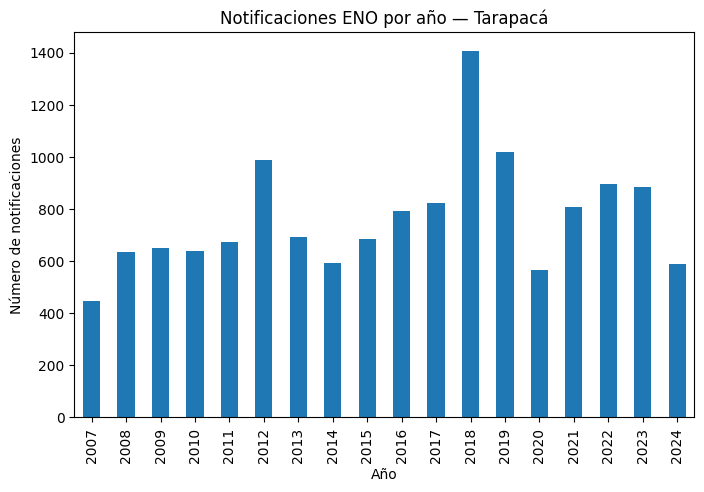

In [ ]:
notifications_by_year = eno_tar["anho_notificacion"].value_counts().sort_index()
print(notifications_by_year)

notifications_by_year.plot(kind="bar", figsize=(8,5))
plt.title("Notificaciones ENO por año — Tarapacá")
plt.xlabel("Año")
plt.ylabel("Número de notificaciones")
plt.show()

En general podemos ver que las notificaciones en la region de tarapaca se mantienen estables con excepciones en los años 2012 y 2018, lo que se podría decir que es aleatorio.
En el año 2012 se puede explicar este aumento debido a un brote de hepatitis a en la región, lo que haría aumentar la cantidad de notificaciones.
Por otro lado, en el año 2018 hubo un aumento en las enfermades de transmisión alimenticia, además de cambios en temas migratorios, con un aumento de flujo de personas ha

2.4 Top 5 enfermedades

ENO
Sifilis                 4127
Infección gonocócica    1967
VIH                     1837
Hepatitis A             1727
Parotiditis             1611
Name: count, dtype: int64


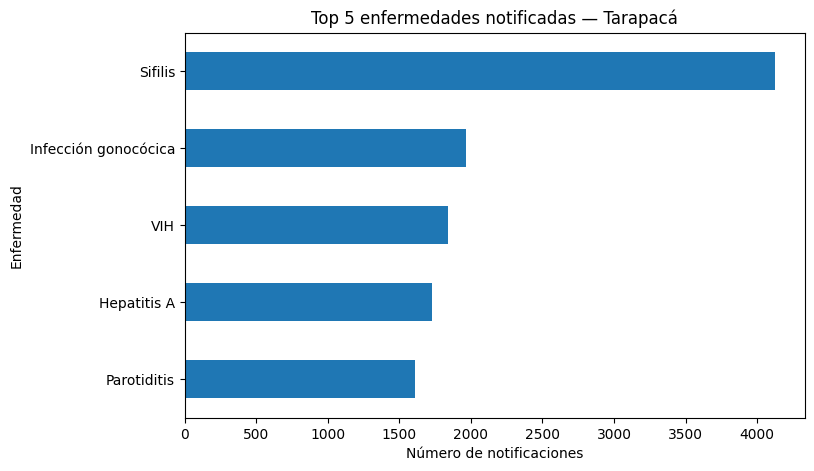

In [ ]:
#Filtrar el top 5 de enfermedades y contar sus notificaciones
top5_diseases = eno_tar["ENO"].value_counts().head(5)
print(top5_diseases)
#Graficar
top5_diseases.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Top 5 enfermedades notificadas — Tarapacá")
plt.xlabel("Número de notificaciones")
plt.ylabel("Enfermedad")
plt.show()

2.5 Distribucion nacional

nacionalidad
Desconocido    6235
Chile          4197
Extranjero     3346
Name: count, dtype: int64


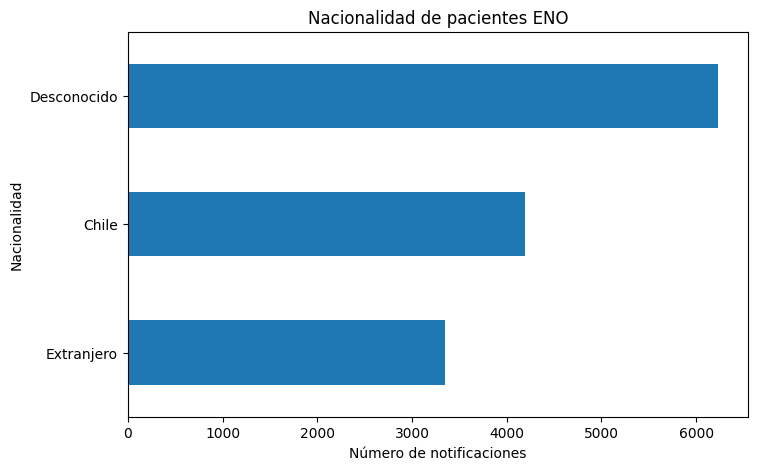

In [ ]:
nationality_distribution = eno_tar["nacionalidad"].value_counts()
print(nationality_distribution)
nationality_distribution.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Nacionalidad de pacientes ENO")
plt.xlabel("Número de notificaciones")
plt.ylabel("Nacionalidad")
plt.show()

En este caso podemos ver que la mayoria de registros está asignada a nacionalidad desconocida, por lo que lo para no perder informacion se decide mantener como un grupo aparte, pero aún así, el mantener estos datos nos entrega resultados con una gran cantidad de incertidumbre sobre la verdadera distribucion entre chilenos y extranjeros

Parte 3. GRD


In [ ]:
import pandas as pd
import zipfile
import matplotlib.pyplot as plt

3.1 carga de 1 año (2024)

In [ ]:
#columnas necesarias
cols = ["COMUNA", "NACIONALIDAD", "SEXO", "DIAGNOSTICO1",
        "FECHA_INGRESO", "FECHAALTA",
        "IR_29301_SEVERIDAD", "IR_29301_COD_GRD"]
#lecutra archivo zip
with zipfile.ZipFile("/content/drive/MyDrive/Prep datos/grd/GRD_PUBLICO_2024.zip") as z:
    with z.open("GRD_PUBLICO_2024.txt") as f:
        grd = pd.read_csv(f, sep="|", usecols=cols, low_memory=False, encoding="latin1")
#conteo de 2024
print(f"Total egresos 2024: {len(grd):,}")

Total egresos 2024: 1,085,813


3.2 Filtrar para Tarapacá

In [ ]:
comunas_tarapaca = ["IQUIQUE", "ALTO HOSPICIO",
                    "POZO ALMONTE", "HUARA", "CAMIÑA",
                    "COLCHANE", "PICA"]

grd_tar = grd[grd["COMUNA"].isin(comunas_tarapaca)]
print(f"Tarapacá: {len(grd_tar):,}")

Tarapacá: 21,063


3.3 Unir con el CIE-10

In [ ]:
cie10 = pd.read_excel("/content/drive/MyDrive/Prep datos/grd/CIE-10.xlsx",
                      sheet_name="CIE 10")

grd_tar = grd_tar.merge(
    cie10[["Código", "Descripción", "Capítulo"]],
    left_on="DIAGNOSTICO1", right_on="Código",
    how="left"
)

3.4 Top 5 diagnosticos

Descripción
Catarata senil, no especificada                             672
Sesión de quimioterapia por tumor                           658
Parto único espontáneo, presentación cefálica de vértice    571
Cálculo de la vesícula biliar con colecistitis aguda        440
Apendicitis aguda, otra y no especificada                   378
Name: count, dtype: int64


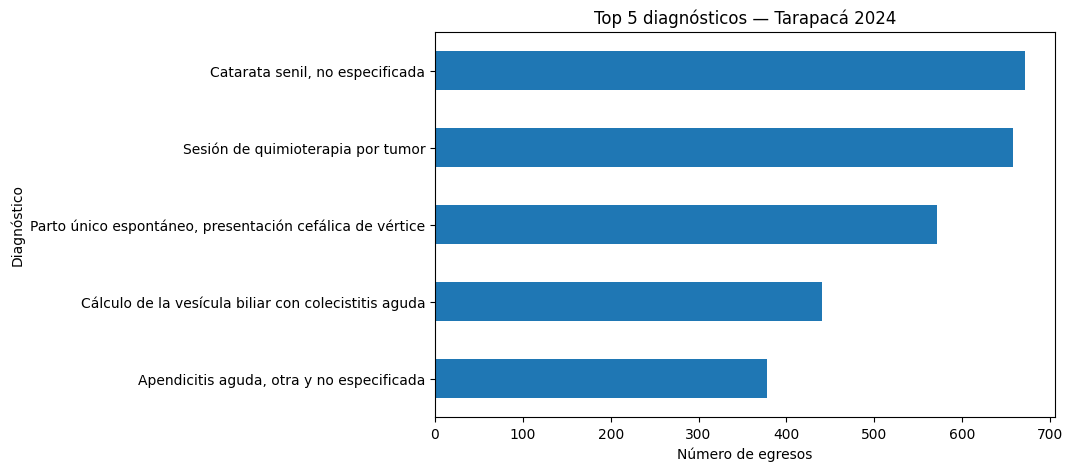

In [ ]:
top5_diag = grd_tar["Descripción"].value_counts().head(5)
print(top5_diag)

top5_diag.sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Top 5 diagnósticos — Tarapacá 2024")
plt.xlabel("Número de egresos")
plt.ylabel("Diagnóstico")
plt.show()

El grafico muestra los 5 diagnosticos mas frecuentes en los egresos hospitalarios de Tarapaca en 2024. El diagnostico mas comun es "Catarata senil, no especificada", seguido por sesiones de quimioterapia por tumor y parto unico espontaneo. Esto sugiere que una parte importante de las hospitalizaciones esta asociada a tanto tratamientos cronicos (como oncologia) como a procedimientos comunes relacionados con envejecimiento y maternidad. ademas de condiciones como apendicitis y enfermedades.